# TarKG KG Embedding Training With `SamplerEngine` and `tf_gnns`

This notebook trains contrastive KG embeddings from the local TarKG artifacts using GestaltDB's new array-native sampler stack.

It demonstrates:

- loading the local `example/gnn_kg` configuration,
- building/loading a `SamplerSnapshot` through the `SamplerEngine`-backed TarKG sampler,
- streaming sampled subgraph batches into TensorFlow,
- training a small `tf_gnns` message-passing model with contrastive negatives,
- exporting learned node and relation embeddings.

Expected local data layout: `data/tarkg_gnn/artifacts/edge_arrays.npz`, `node_map.parquet`, and `relation_map.parquet`. Run `example/gnn_kg/prepare_tarkg.py` first if those files are missing.

In [ ]:
from __future__ import annotations

import os
import sys
import time
from pathlib import Path

os.environ.setdefault("KERAS_BACKEND", "tensorflow")

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd().parent

for path in (PROJECT_ROOT, PROJECT_ROOT / "src"):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print("Project root:", PROJECT_ROOT)

Project root: /home/charilaos/Workspace/gestaltdb


In [9]:
import numpy as np
import tensorflow as tf
from tf_gnns import GraphNetMPNN_MLP

from example.gnn_kg.config import make_config
from example.gnn_kg.sampler import SamplerEngineKGNeighborhoodSampler

gpus = tf.config.list_physical_devices("GPU")
if not gpus:
    raise RuntimeError(
        "TensorFlow cannot see a GPU. Select the `GestaltDB GNN KG (CUDA)` Jupyter kernel, "
        "or launch training through `bash example/gnn_kg/run_training.sh`."
    )
for gpu in gpus:
    tf.config.experimental.set_memory_growth(gpu, True)
with tf.device("/GPU:0"):
    gpu_probe = tf.linalg.matmul(tf.ones((128, 128)), tf.ones((128, 128)))
print("TensorFlow:", tf.__version__)
print("GPUs:", gpus)
print("GPU probe device:", gpu_probe.device)

I0000 00:00:1787551091.813259  370030 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787551091.843590  370030 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1787551092.472402  370030 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow: 2.21.0
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU probe device: /job:localhost/replica:0/task:0/device:GPU:0


I0000 00:00:1787551093.289516  370030 gpu_device.cc:2043] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 21086 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 4090, pci bus id: 0000:01:00.0, compute capability: 8.9


## 2. Configure Sampler and Check Artifacts

The sampler uses the new generic `SamplerSnapshot.from_edge_arrays(...)` path internally. The first construction may create `data/tarkg_gnn/artifacts/sampler_snapshot/`; later runs load that snapshot directly.

In [31]:
cfg = make_config(smoke_test=False)
cfg.sampler.batch_size = 64
cfg.sampler.negatives_per_positive = 8
cfg.sampler.hop1_fanout = 12
cfg.sampler.hop2_fanout = 8
cfg.sampler.engine_negative_source = "context_relation_neighbors"
cfg.model.hidden_dim = 512
cfg.model.mp_steps = 2
cfg.training.learning_rate = 1e-4

required = [cfg.paths.edge_arrays_path, cfg.paths.node_map_path, cfg.paths.relation_map_path]
missing = [path for path in required if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Missing TarKG artifacts. Run `python example/gnn_kg/prepare_tarkg.py --skip-ingest` first. Missing: "
        + ", ".join(str(path) for path in missing)
    )

sampler = SamplerEngineKGNeighborhoodSampler(cfg)
print("nodes:", f"{sampler.num_nodes:,}")
print("relations:", f"{sampler.num_relations:,}")
print("node types:", f"{sampler.num_node_types:,}")

nodes: 998,869
relations: 14
node types: 10


In [32]:
batch = sampler.sample_batch()
print("sampled nodes:", len(batch.node_ids))
print("sampled edges:", len(batch.edge_rel_ids))
print("positives:", batch.positive_src.shape)
print("negatives:", batch.negative_src.shape)

sampled nodes: 8422
sampled edges: 12676
positives: (64,)
negatives: (64, 8)


## 3. Convert Sampled Batches to Tensor Dictionaries

`tf_gnns` consumes a lightweight tensor dictionary containing node features, edge features, connectivity, and packed graph sizes. Labels hold positive and negative triples in local batch node IDs.

In [33]:
def sampled_batch_to_tensor_dict(batch):
    graph = {
        "nodes": tf.convert_to_tensor(np.stack([batch.node_global_ids, batch.node_type_ids], axis=1), dtype=tf.float32),
        "edges": tf.convert_to_tensor(batch.edge_rel_ids[:, None], dtype=tf.float32),
        "senders": tf.convert_to_tensor(batch.senders, dtype=tf.int64),
        "receivers": tf.convert_to_tensor(batch.receivers, dtype=tf.int64),
        "n_nodes": tf.convert_to_tensor([len(batch.node_ids)], dtype=tf.int64),
        "n_edges": tf.convert_to_tensor([len(batch.edge_rel_ids)], dtype=tf.int64),
        "n_graphs": tf.convert_to_tensor(1, dtype=tf.int64),
    }
    labels = {
        "positive_src": tf.convert_to_tensor(batch.positive_src, dtype=tf.int64),
        "positive_dst": tf.convert_to_tensor(batch.positive_dst, dtype=tf.int64),
        "positive_rel": tf.convert_to_tensor(batch.positive_rel, dtype=tf.int64),
        "negative_src": tf.convert_to_tensor(batch.negative_src, dtype=tf.int64),
        "negative_dst": tf.convert_to_tensor(batch.negative_dst, dtype=tf.int64),
        "negative_rel": tf.convert_to_tensor(batch.negative_rel, dtype=tf.int64),
    }
    return graph, labels

def output_signature(negatives_per_positive: int):
    graph_sig = {
        "nodes": tf.TensorSpec(shape=(None, 2), dtype=tf.float32),
        "edges": tf.TensorSpec(shape=(None, 1), dtype=tf.float32),
        "senders": tf.TensorSpec(shape=(None,), dtype=tf.int64),
        "receivers": tf.TensorSpec(shape=(None,), dtype=tf.int64),
        "n_nodes": tf.TensorSpec(shape=(1,), dtype=tf.int64),
        "n_edges": tf.TensorSpec(shape=(1,), dtype=tf.int64),
        "n_graphs": tf.TensorSpec(shape=(), dtype=tf.int64),
    }
    labels_sig = {
        "positive_src": tf.TensorSpec(shape=(None,), dtype=tf.int64),
        "positive_dst": tf.TensorSpec(shape=(None,), dtype=tf.int64),
        "positive_rel": tf.TensorSpec(shape=(None,), dtype=tf.int64),
        "negative_src": tf.TensorSpec(shape=(None, negatives_per_positive), dtype=tf.int64),
        "negative_dst": tf.TensorSpec(shape=(None, negatives_per_positive), dtype=tf.int64),
        "negative_rel": tf.TensorSpec(shape=(None, negatives_per_positive), dtype=tf.int64),
    }
    return graph_sig, labels_sig

graph, labels = sampled_batch_to_tensor_dict(batch)
print(graph.keys())
print(labels.keys())

dict_keys(['nodes', 'edges', 'senders', 'receivers', 'n_nodes', 'n_edges', 'n_graphs'])
dict_keys(['positive_src', 'positive_dst', 'positive_rel', 'negative_src', 'negative_dst', 'negative_rel'])


## 4. Build a `tf.data` Feeder

The Python sampler runs outside TensorFlow and yields NumPy-backed batches. `tf.data.Dataset.from_generator` converts those batches to tensors and prefetches to overlap sampling with model execution.

In [34]:
def dataset_from_sampler(sampler, prefetch: int = 2):
    def gen():
        while True:
            yield sampled_batch_to_tensor_dict(sampler.sample_batch())

    return tf.data.Dataset.from_generator(
        gen,
        output_signature=output_signature(sampler.cfg.sampler.negatives_per_positive),
    ).prefetch(prefetch)

ds = dataset_from_sampler(sampler, prefetch=2)
next_graph, next_labels = next(iter(ds.take(1)))
print("nodes tensor:", next_graph["nodes"].shape)
print("negative tensor:", next_labels["negative_src"].shape)

nodes tensor: (8172, 2)
negative tensor: (64, 8)


## 5. Define the Contrastive KG Embedding Model

The model learns node ID, node type, and relation embeddings, performs message passing over each sampled subgraph with `tf_gnns.GraphNetMPNN_MLP`, then scores positive and negative triples with a DistMult-style trilinear score.

In [35]:
class KGContrastiveModel(tf.keras.Model):
    def __init__(self, cfg, *, num_nodes: int, num_node_types: int, num_relations: int):
        super().__init__()
        self.cfg = cfg
        self.node_id_emb = tf.keras.layers.Embedding(num_nodes, cfg.node_id_embedding_dim)
        self.node_type_emb = tf.keras.layers.Embedding(num_node_types, cfg.node_type_embedding_dim)
        self.rel_emb = tf.keras.layers.Embedding(num_relations, cfg.relation_embedding_dim)
        self.node_proj = tf.keras.layers.Dense(cfg.hidden_dim, activation="relu")
        self.edge_proj = tf.keras.layers.Dense(cfg.hidden_dim, activation="relu")
        self.gnn = GraphNetMPNN_MLP(
            units=cfg.hidden_dim,
            core_units=cfg.hidden_dim,
            core_size=cfg.hidden_dim,
            gi_units=cfg.hidden_dim,
            core_steps=cfg.mp_steps,
            node_output_size=cfg.hidden_dim,
            edge_output_size=cfg.hidden_dim,
            aggregation_function=cfg.aggregation_function,
        )
        self.dropout = tf.keras.layers.Dropout(cfg.dropout)
        self.score_rel = tf.keras.layers.Embedding(num_relations, cfg.hidden_dim)

    def encode(self, graph: dict[str, tf.Tensor], training: bool = False) -> tf.Tensor:
        node_global = tf.cast(graph["nodes"][:, 0], tf.int64)
        node_type = tf.cast(graph["nodes"][:, 1], tf.int64)
        edge_rel = tf.cast(graph["edges"][:, 0], tf.int64)
        graph_in = dict(graph)
        graph_in["nodes"] = self.node_proj(tf.concat([self.node_id_emb(node_global), self.node_type_emb(node_type)], axis=-1))
        graph_in["edges"] = self.edge_proj(self.rel_emb(edge_rel))
        out = self.gnn(graph_in)
        return self.dropout(out["nodes"], training=training)

    def _score(self, nodes: tf.Tensor, src: tf.Tensor, rel: tf.Tensor, dst: tf.Tensor) -> tf.Tensor:
        src_h = tf.gather(nodes, src)
        dst_h = tf.gather(nodes, dst)
        rel_h = self.score_rel(rel)
        return tf.reduce_sum(src_h * rel_h * dst_h, axis=-1)

    def call(self, graph: dict[str, tf.Tensor], labels: dict[str, tf.Tensor], training: bool = False):
        nodes = self.encode(graph, training=training)
        pos = self._score(nodes, labels["positive_src"], labels["positive_rel"], labels["positive_dst"])
        neg_shape = tf.shape(labels["negative_src"])
        neg = self._score(
            nodes,
            tf.reshape(labels["negative_src"], [-1]),
            tf.reshape(labels["negative_rel"], [-1]),
            tf.reshape(labels["negative_dst"], [-1]),
        )
        return pos, tf.reshape(neg, neg_shape)

def contrastive_infonce_loss(positive_logits: tf.Tensor, negative_logits: tf.Tensor, temperature: float) -> tf.Tensor:
    logits = tf.concat([positive_logits[:, tf.newaxis], negative_logits], axis=1) / temperature
    labels = tf.zeros(tf.shape(positive_logits)[0], dtype=tf.int32)
    return tf.reduce_mean(tf.keras.losses.sparse_categorical_crossentropy(labels, logits, from_logits=True))

## 6. Train

For an initial run, keep `TRAIN_STEPS` small. Increase it once the data pipeline and GPU setup are validated.

In [ ]:
model = KGContrastiveModel(
    cfg.model,
    num_nodes=sampler.num_nodes,
    num_node_types=sampler.num_node_types,
    num_relations=sampler.num_relations,
)




In [155]:
optimizer = tf.keras.optimizers.Adam(learning_rate=cfg.training.learning_rate * 0.1)

train_step_signature = output_signature(cfg.sampler.negatives_per_positive)

@tf.function(input_signature=train_step_signature, reduce_retracing=True)
def train_step(graph, labels):
    with tf.GradientTape() as tape:
        pos, neg = model(graph, labels, training=True)
        loss = contrastive_infonce_loss(pos, neg, cfg.model.temperature)
    grads = tape.gradient(loss, model.trainable_variables)
    grads_and_vars = [(grad, var) for grad, var in zip(grads, model.trainable_variables) if grad is not None]
    optimizer.apply_gradients(grads_and_vars)
    return loss, tf.shape(graph["nodes"])[0], tf.shape(graph["edges"])[0]

In [156]:
history = []

In [ ]:
TRAIN_STEPS = 200_000
LOG_EVERY = 50

started = time.perf_counter()
for step, (graph, labels) in enumerate(ds.take(TRAIN_STEPS), start=1):
    loss, n_nodes, n_edges = train_step(graph, labels)
    loss_value = float(loss)
    history.append(loss_value)
    if step == 1 or step % LOG_EVERY == 0:
        elapsed = max(time.perf_counter() - started, 1e-6)
        print(
            f"step={step:04d} loss={loss_value:.4f} nodes={int(n_nodes):,} edges={int(n_edges):,} "
            f"steps_per_s={step / elapsed:.2f}"
        )


In [144]:
lrate_str = '%2.2E'%cfg.training.learning_rate
model.save_weights(f'model_hist{len(history)}_{lrate_str}.weights.h5')
# model.load_weights('model.weights.h5')


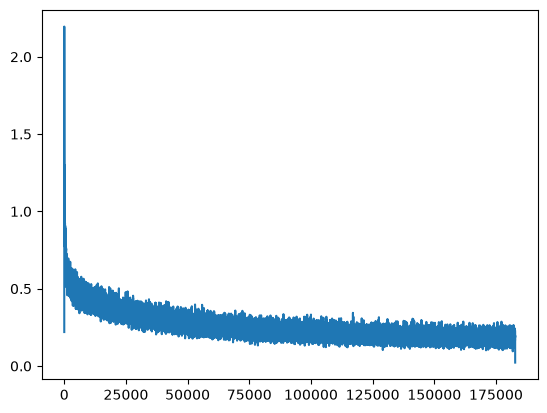

In [154]:
import seaborn as sns
import matplotlib.pyplot as pplot
import numpy as np
hist_smooth = np.convolve(np.ones(10)/10., history)
# pplot.semilogx(hist_smooth[100:])
pplot.plot(hist_smooth)


## 7. Export Learned Embeddings

This saves the trainable lookup embeddings. The contextual GNN embeddings are batch-dependent; for most downstream KG use, the node ID and relation scoring embeddings are the reusable artifacts.

In [174]:
output_path = cfg.paths.artifacts_dir / "tfgnns_sampler_engine_embeddings.npz"
output_path.parent.mkdir(parents=True, exist_ok=True)
np.savez_compressed(
    output_path,
    node_id_embeddings=model.node_id_emb.get_weights()[0],
    node_type_embeddings=model.node_type_emb.get_weights()[0],
    relation_message_embeddings=model.rel_emb.get_weights()[0],
    relation_score_embeddings=model.score_rel.get_weights()[0],
    loss_history=np.asarray(history, dtype=np.float32),
)
print("saved embeddings to", output_path)

saved embeddings to /home/charilaos/Workspace/gestaltdb/data/tarkg_gnn/artifacts/tfgnns_sampler_engine_embeddings.npz


In [175]:
node_emb = model.node_id_emb.get_weights()[0]

In [176]:
from sklearn.decomposition import PCA
res_pca = PCA(n_components=4).fit_transform(node_emb[::58])

In [177]:
from sklearn.manifold import TSNE
res = TSNE().fit_transform(res_pca)

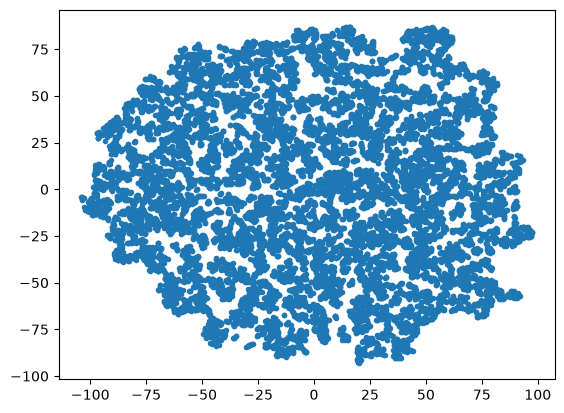

In [178]:
import matplotlib.pyplot as pplot
pplot.plot(res[:,0], res[:,1],'.')

## 8. Optional: Inspect Similar Nodes

The snippet below computes nearest neighbors by cosine similarity over the learned node ID embeddings. For large node counts, use an ANN library instead of the dense matrix product.

In [173]:
def nearest_nodes(node_int: int, k: int = 10):
    emb = model.node_id_emb.get_weights()[0].astype(np.float32)
    emb = emb / np.maximum(np.linalg.norm(emb, axis=1, keepdims=True), 1e-9)
    scores = emb @ emb[node_int]
    order = np.argpartition(-scores, kth=min(k + 1, len(scores) - 1))[: k + 1]
    order = order[np.argsort(-scores[order])]
    return [(int(idx), float(scores[idx])) for idx in order if idx != node_int][:k]

nearest_nodes(0, k=5)

[(104741, 0.3972478210926056),
 (657984, 0.3908756971359253),
 (937904, 0.39031827449798584),
 (919644, 0.38958740234375),
 (842994, 0.38892635703086853)]